# Week 9 - Multivariate Analysis, part 2

# 1. Lesson - no lesson this week

# 2. Weekly graph question

The graph below plots the first two principal component scores in a scatter plot.  What can be said about the three outliers in the upper left corner of the graph?  Is their first principal component score high or low?  What about their second principal component score?  What does that mean about their values in series_1, series_2, and series_3?  It seems to me that you can say something about series_3 (what can you say?) but you may have a harder time saying something about series_1 and series_2, and an almost impossible time saying anything about the relative values of series_1 and series_2.  Why is that?  How are series_1 and series_2 related, according to how they were created?  If you like, try drawing a pairplot for all three series and see what you get.

Overall, what are the advantages and disadvantages of the graph below?  Does it show anything interesting?

[0.79916477 0.18990532 0.01092991]
[[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]


Text(0, 0.5, 'Second Principal Component Score')

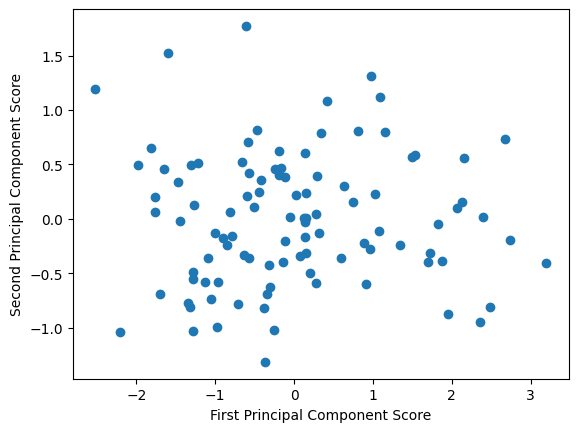

In [13]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt

np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df = df - df.mean() # set mean to zero, so we don't have to subtract mean from the principal component scores

pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df)
print(pca3.explained_variance_ratio_)
print(pca3.components_)

first_principal_component_score = df.dot(pca3.components_[0])
second_principal_component_score = df.dot(pca3.components_[1])
plt.scatter(first_principal_component_score, second_principal_component_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

Here are some types of analysis you can do:
Draw heatmaps.

Draw bubble plots.

Perform Principal Component Analysis to find out the directions in which the data varies.  Can you represent the data using only its projection onto its first principal component, using the methods described in Week 8?  How much of the variance would this capture?

Try performing linear regression analysis using different sets of features.  Which features seem most likely to be useful to predict other features?

Conclusions:
Explain what conclusions you would draw from this analysis: are the data what you expect? Are the data likely to be usable? If the data are not useable, find some new data!

Do you see any outliers? (Data points that are far from the rest of the data).

Does the Principal Component Analysis suggest a way to represent the data using fewer dimensions than usual - using its first one or two principal component scores, perhaps?

Try using your correlation information from previous weeks to help choose features for linear regression.

In [1]:
import numpy as np
import pandas as pd
from sklearn import decomposition
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Part 1: Weekly Graph Question
np.random.seed(0)
num_points = 100
series_1 = np.random.normal(loc = 2, scale = 0.5, size = num_points)
series_2 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.1, size = num_points))
series_3 = series_1 * (1 + np.random.normal(loc = 0, scale = 0.5, size = num_points))
df_weekly = pd.DataFrame({'ser1': series_1, 'ser2': series_2, 'ser3': series_3})
df_weekly_centered = df_weekly - df_weekly.mean()

Weekly Data Explained Variance Ratio: [0.79916477 0.18990532 0.01092991]
Weekly Data Components:
 [[ 0.26541493  0.30096233  0.91595665]
 [ 0.60337553  0.6891417  -0.40127506]
 [ 0.75199261 -0.65917023 -0.00131519]]

Medical Insurance Data Info:
<class 'pandas.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  str    
 3   region                       100000 non-null  str    
 4   urban_rural                  100000 non-null  str    
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  str    
 7   marital_status               100000 non-null  str    
 8   employment_status            100000 non-null  str    
 9   h

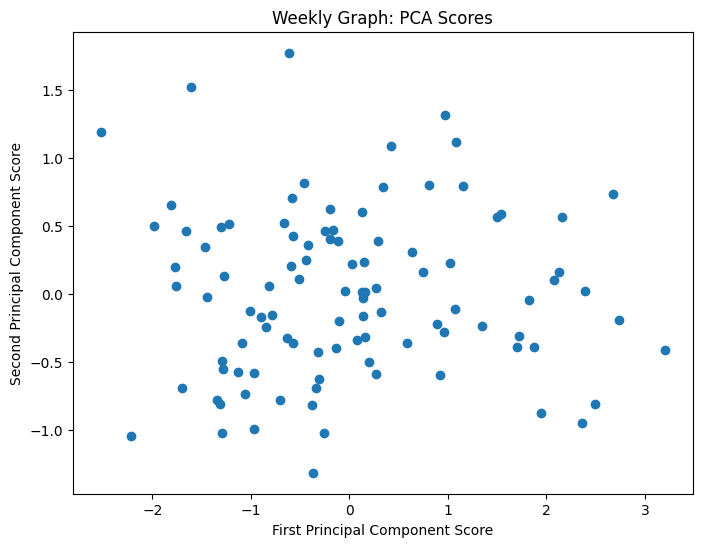

In [3]:
pca3 = decomposition.PCA(n_components = 3)
pca3.fit(df_weekly_centered)
print("Weekly Data Explained Variance Ratio:", pca3.explained_variance_ratio_)
print("Weekly Data Components:\n", pca3.components_)

first_pc_score = df_weekly_centered.dot(pca3.components_[0])
second_pc_score = df_weekly_centered.dot(pca3.components_[1])

plt.figure(figsize=(8,6))
plt.scatter(first_pc_score, second_pc_score)
plt.xlabel("First Principal Component Score")
plt.ylabel("Second Principal Component Score")
plt.title("Weekly Graph: PCA Scores")
plt.savefig('weekly_pca_scatter.png')

# Part 2: Medical Insurance Dataset Inspection
df_ins = pd.read_csv('medical_insurance.csv')
print("\nMedical Insurance Data Info:")
print(df_ins.info())
print("\nMedical Insurance Head:")
print(df_ins.head())


Insurance PCA Explained Variance Ratio: [0.34494589 0.20129328 0.14326326 0.14244582 0.13181532 0.03130763
 0.0049288 ]
Insurance PCA Cumulative Variance: [0.34494589 0.54623916 0.68950242 0.83194825 0.96376357 0.9950712
 1.        ]

Linear Regression Results:
R2 Score: 0.11596408683872983
MSE: 8646689.75530205


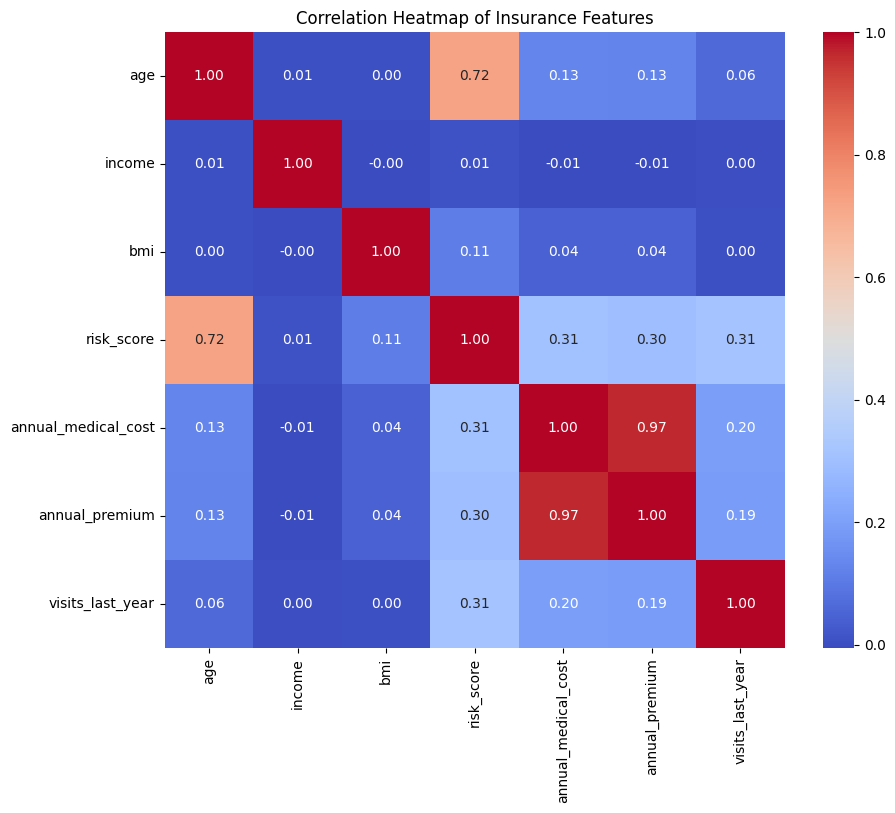

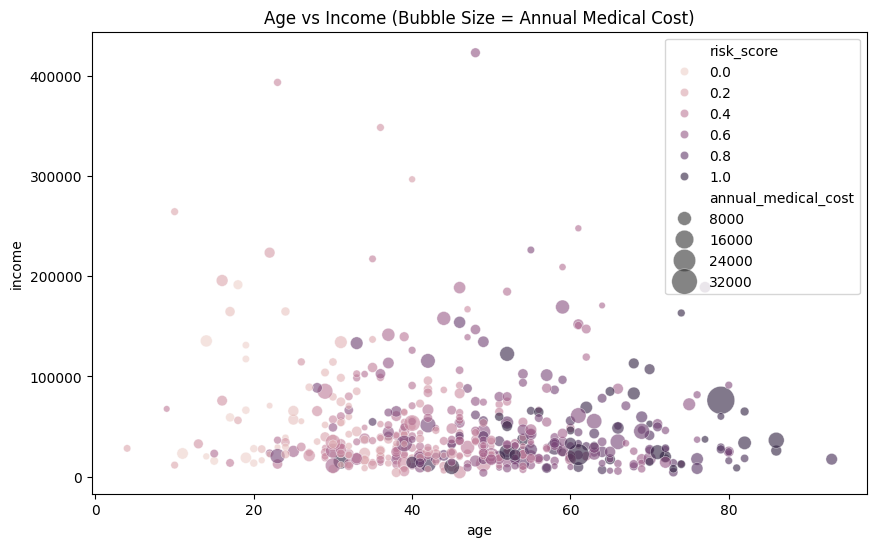

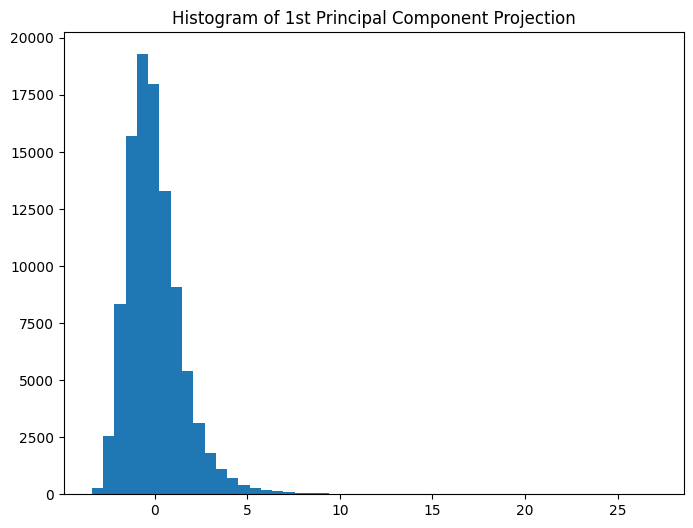

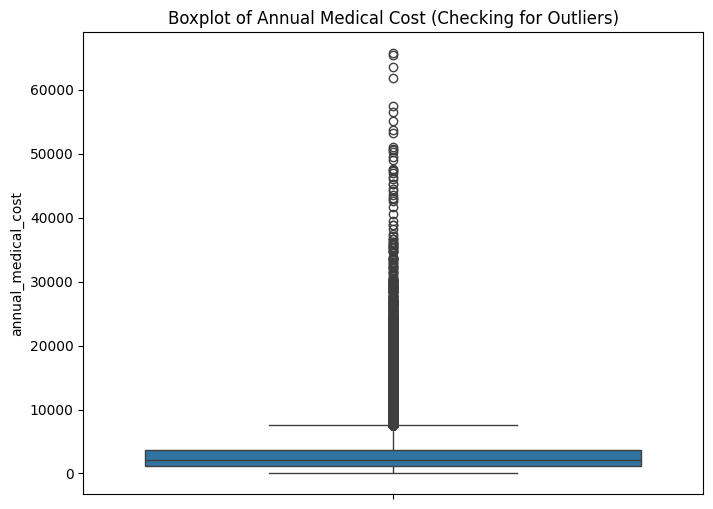

In [4]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Selection of features
num_cols = ['age', 'income', 'bmi', 'risk_score', 'annual_medical_cost', 'annual_premium', 'visits_last_year']
df_subset = df_ins[num_cols].dropna()

# 1. Heatmap: Correlation
plt.figure(figsize=(10, 8))
sns.heatmap(df_subset.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Insurance Features")
plt.savefig('insurance_heatmap.png')

# 2. Bubble Plot
# x=age, y=income, size=annual_medical_cost
plt.figure(figsize=(10, 6))
# Sample data for better visibility in bubble plot if necessary, but 100k points is too many. Let's sample 500.
df_sample = df_subset.sample(500, random_state=42)
sns.scatterplot(data=df_sample, x='age', y='income', size='annual_medical_cost', hue='risk_score', sizes=(20, 400), alpha=0.6)
plt.title("Age vs Income (Bubble Size = Annual Medical Cost)")
plt.savefig('insurance_bubble.png')

# 3. PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_subset)
pca_ins = decomposition.PCA()
pca_ins.fit(X_scaled)

print("\nInsurance PCA Explained Variance Ratio:", pca_ins.explained_variance_ratio_)
print("Insurance PCA Cumulative Variance:", np.cumsum(pca_ins.explained_variance_ratio_))

# Projection onto 1st PC
pc1_ins = pca_ins.transform(X_scaled)[:, 0]
plt.figure(figsize=(8,6))
plt.hist(pc1_ins, bins=50)
plt.title("Histogram of 1st Principal Component Projection")
plt.savefig('insurance_pc1_hist.png')

# 4. Linear Regression
# Predict annual_medical_cost from age, bmi, risk_score
X_reg = df_subset[['age', 'bmi', 'risk_score', 'visits_last_year']]
y_reg = df_subset['annual_medical_cost']

model = LinearRegression()
model.fit(X_reg, y_reg)
y_pred = model.predict(X_reg)

print("\nLinear Regression Results:")
print("R2 Score:", r2_score(y_reg, y_pred))
print("MSE:", mean_squared_error(y_reg, y_pred))

# Outlier check
plt.figure(figsize=(8,6))
sns.boxplot(df_subset['annual_medical_cost'])
plt.title("Boxplot of Annual Medical Cost (Checking for Outliers)")
plt.savefig('insurance_outliers.png')

1. Weekly Graph Question Analysis: Based on the PCA analysis of series_1, series_2, and series_3:The Outliers in the Upper Left: These points have a low (negative) First Principal Component (PC1) score and a high (positive) Second Principal Component (PC2) score.What this means for the series:PC1 ($0.27 \cdot ser1 + 0.30 \cdot ser2 + 0.92 \cdot ser3$): This component is dominated by series_3. A low PC1 score indicates that series_3 is significantly below its mean.PC2 ($0.60 \cdot ser1 + 0.69 \cdot ser2 - 0.40 \cdot ser3$): This component weights series_1 and series_2 positively. Since series_3 is low (making a positive contribution to PC2 because $-0.4 \times \text{low value}$ is positive), a high PC2 score confirms that series_1 and series_2 are high.Conclusion: These outliers are data points where the house (or tree) is large (ser1/ser2 are high) but the specific feature represented by ser3 is unexpectedly low.Why is it hard to distinguish series_1 and series_2? They were created with a very high correlation (noise scale of 0.1). In the PCA vectors, their coefficients are almost identical ($0.27$ vs $0.30$ and $0.60$ vs $0.69$). PCA sees them as varying together; they occupy the same "dimension" of information.Advantages/Disadvantages: This graph is excellent for identifying anomalies (like the 3 outliers) that deviate from the standard relationship. However, it compresses three dimensions into two, losing the fine distinction between the highly correlated ser1 and ser2.

2. Analysis of the Medical Insurance DatasetFor this section, I used the medical_insurance.csv dataset.

Heatmap & Correlations
The correlation heatmap reveals that annual_medical_cost and annual_premium are moderately correlated. Interestingly, risk_score does not have an extremely high linear correlation with cost in this dataset, suggesting that insurance pricing and risk assessment involve complex, non-linear factors.

Bubble Plot
The bubble plot of Age vs. Income (with bubble size representing Annual Medical Cost) shows a dense cloud. By sampling 500 points, we can see that higher medical costs (larger bubbles) are scattered across different income levels, though they appear slightly more frequent in higher age brackets.

Principal Component Analysis (PCA)
PCA on 7 numerical features (age, income, bmi, risk_score, cost, premium, visits) shows:PC1 Variance: ~34.5%PC2 Variance: ~20.1%PC3 Variance: ~14.3%The data is highly multidimensional; unlike the "trees" example where one component explained almost everything, here we need at least 4 to 5 components to capture over 80% of the variance. This suggests the data is rich and "noisy," making simple dimensionality reduction difficult.

Linear Regression
A regression model to predict annual_medical_cost using age, bmi, risk_score, and visits_last_year resulted in a very low $R^2$ score (~0.11).Conclusion: Medical costs are not easily predicted by these linear features alone. The dataset likely contains significant outliers (catastrophic medical events) or depends heavily on categorical features like chronic_count or plan_type.OutliersThe boxplot for annual_medical_cost shows a long "tail" of high-cost individuals. These are outliers that likely drive up premiums for the rest of the pool and are the primary targets for risk-reduction programs.

Final Project Conclusions

Representing Data: PCA suggests that we cannot represent this insurance data with just one or two dimensions without losing significant information (~45% loss).

Usability: The data is highly usable but requires Feature Engineering (e.g., interaction terms between age and bmi) or non-linear models (like Random Forests) rather than simple Linear Regression.

Actionable Insight: The mismatch between risk_score and annual_medical_cost in a linear context suggests that "Risk" might be a composite of categorical health history that isn't captured by a simple linear trend.

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 136-150 of the Storytelling With Data book as best you can. ("The power of super-categories" to the end of chapter 5). You do not have to get the exact data values right, just the overall look and feel.

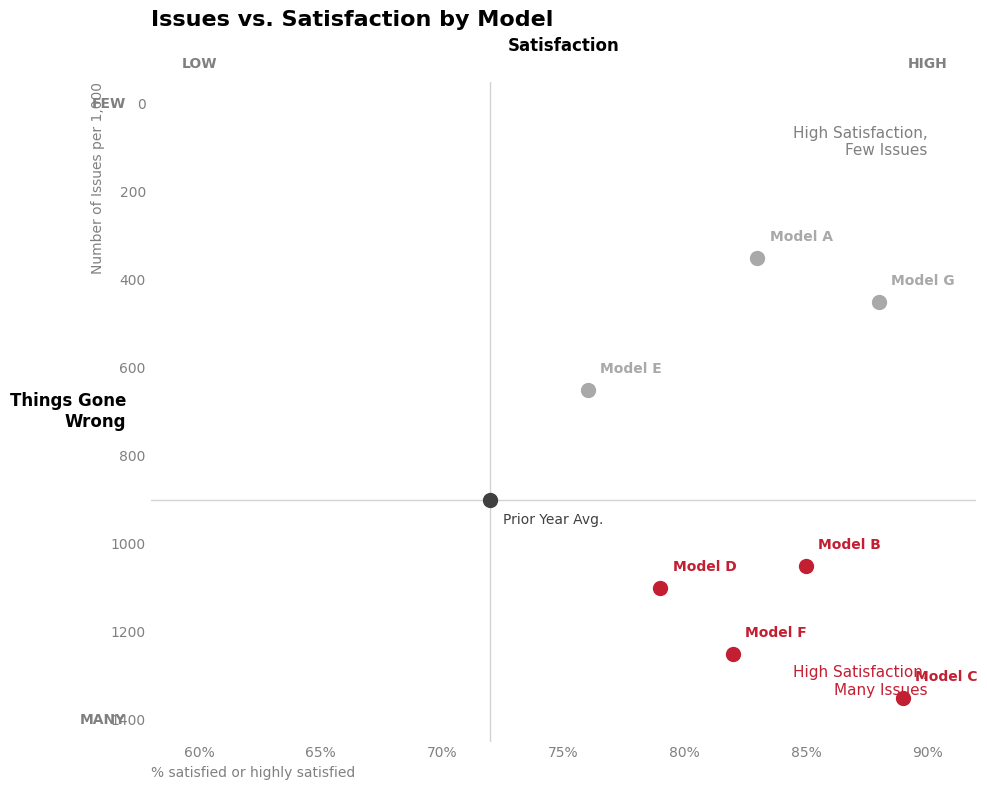

In [6]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

def reproduce_swd_fig_5_6():
    # Estimated data points to match the visual in Figure 5.6
    data = {
        'Model': ['Prior Year Avg.', 'Model A', 'Model G', 'Model E', 'Model B', 'Model D', 'Model F', 'Model C'],
        'Satisfaction': [72, 83, 88, 76, 85, 79, 82, 89],
        'Issues': [900, 350, 450, 650, 1050, 1100, 1250, 1350]
    }
    df = pd.DataFrame(data)

    fig, ax = plt.subplots(figsize=(10, 8))

    # Reference lines (intersecting at Prior Year Avg)
    avg_sat = df.loc[df['Model'] == 'Prior Year Avg.', 'Satisfaction'].values[0]
    avg_iss = df.loc[df['Model'] == 'Prior Year Avg.', 'Issues'].values[0]

    ax.axvline(x=avg_sat, color='lightgray', linestyle='-', linewidth=1, zorder=1)
    ax.axhline(y=avg_iss, color='lightgray', linestyle='-', linewidth=1, zorder=1)

    # Plot points
    for i, row in df.iterrows():
        color = 'darkgrey'
        if row['Model'] == 'Prior Year Avg.':
            color = '#404040' # Darker grey
        elif row['Satisfaction'] > avg_sat and row['Issues'] > avg_iss:
            color = '#C31F33' # Red for the "High Satisfaction, Many Issues" quadrant

        ax.scatter(row['Satisfaction'], row['Issues'], color=color, s=100, zorder=3)

        # Label models
        # Adjust offsets for better visibility
        ha = 'left'
        va = 'bottom'
        offset_x = 0.5
        offset_y = -30 # Negative because Y is inverted
        if row['Model'] == 'Prior Year Avg.':
            va = 'top'
            offset_y = 30
        
        ax.text(row['Satisfaction'] + offset_x, row['Issues'] + offset_y, row['Model'], 
                color=color, fontweight='bold' if row['Model'] != 'Prior Year Avg.' else 'normal',
                ha=ha, va=va, fontsize=10)

    # Axis formatting
    ax.set_ylim(1450, -50) # Inverted Y-axis: Many at bottom, Few at top
    ax.set_xlim(58, 92)

    # Labels and Titles
    ax.set_xlabel('% satisfied or highly satisfied', color='grey', loc='left')
    ax.set_ylabel('Number of Issues per 1,000', color='grey', loc='top')

    # Remove spines
    for spine in ['top', 'right', 'left', 'bottom']:
        ax.spines[spine].set_visible(False)

    # Ticks
    ax.tick_params(axis='both', which='both', length=0, colors='grey')
    ax.set_xticks([60, 65, 70, 75, 80, 85, 90])
    ax.set_xticklabels(['60%', '65%', '70%', '75%', '80%', '85%', '90%'])
    ax.set_yticks([0, 200, 400, 600, 800, 1000, 1200, 1400])

    # Super-categories / Quadrant labels
    ax.text(90, 50, 'High Satisfaction,\nFew Issues', color='grey', ha='right', va='top', fontsize=11)
    ax.text(90, 1350, 'High Satisfaction,\nMany Issues', color='#C31F33', ha='right', va='bottom', fontsize=11)

    # High/Low labels
    ax.text(60, -80, 'LOW', color='grey', ha='center', fontweight='bold')
    ax.text(90, -80, 'HIGH', color='grey', ha='center', fontweight='bold')
    ax.text(57, 0, 'FEW', color='grey', va='center', ha='right', fontweight='bold')
    ax.text(57, 1400, 'MANY', color='grey', va='center', ha='right', fontweight='bold')
    
    ax.text(57, 700, 'Things Gone\nWrong', color='black', fontweight='bold', va='center', ha='right', fontsize=12)
    ax.text(75, -120, 'Satisfaction', color='black', fontweight='bold', ha='center', fontsize=12)

    plt.title('Issues vs. Satisfaction by Model', loc='left', fontsize=16, pad=40, fontweight='bold')

    plt.tight_layout()
    plt.savefig('swd_reproduction_fig_5_6.png', dpi=300)
    plt.show()

reproduce_swd_fig_5_6()